# Model 2C, Multilayer Perceptron Experiment 01: Schedule-Margin Network

This append-only experiment tests whether a bounded multilayer perceptron can improve Model 2C using the representation selected by Logistic Regression 2C Experiment 02. It uses the existing `JFK_YEAR_arrivals.csv` dataset and creates no new feature dataset.

The input design contains the same 31 source fields as the selected raw-taxi logistic-regression variant. `MINUTES_TO_SCHEDULED_ARRIVAL = CRSElapsedTime - DepDelay - TaxiOut` is calculated inside the notebook and represented by a fold-fitted spline. Categorical fields are one-hot encoded; numeric and spline inputs are imputed and standardized within each training fold.

Six bounded configurations compare three hidden-layer layouts and two learning rates. The largest `(256, 128, 64, 32)` layout is an upper-bound candidate, not a predetermined choice. Architecture, learning rate, epoch count, and operating threshold are selected only from five expanding 2019 folds. The selected design is refitted on all 2019 rows and evaluated once on 2023. The 2024 dataset is not loaded.

In [1]:
import gc
import os
from itertools import product
from pathlib import Path
from time import perf_counter

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-capstone")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp/xdg-cache-capstone")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import tensorflow as tf
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler
from tensorflow import keras
from tensorflow.keras import layers, regularizers

AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "ArrDel15"
RANDOM_STATE = 42
N_TIME_SPLITS = 5
SPLINE_KNOTS = 5
SPLINE_DEGREE = 3
MAX_EPOCHS = 80
EARLY_STOPPING_PATIENCE = 8

tf.keras.utils.set_random_seed(RANDOM_STATE)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"TensorFlow {tf.__version__}; scikit-learn {sklearn.__version__}")

Matplotlib is building the font cache; this may take a moment.


TensorFlow 2.21.0; scikit-learn 1.9.0


## Load and validate the shared arrival datasets

The experiment uses the same 2019 training rows and 2023 validation rows as the completed Model 2C logistic-regression and CatBoost experiments.

In [2]:
def find_project_root(start: Path, airport: str, years) -> Path:
    required = [
        Path("data/features") / f"{airport}_{year}_arrivals.csv"
        for year in years
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required feature datasets: {required}")


PROJECT_ROOT = find_project_root(Path.cwd().resolve(), AIRPORT, [TRAIN_YEAR, VALIDATION_YEAR])
TRAIN_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{TRAIN_YEAR}_arrivals.csv"
VALIDATION_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{VALIDATION_YEAR}_arrivals.csv"

train_df = pd.read_csv(TRAIN_DATA_PATH, low_memory=False)
validation_df = pd.read_csv(VALIDATION_DATA_PATH, low_memory=False)


def validate_source_frame(frame: pd.DataFrame, year: int, partition: str):
    required = {"FlightDate", "Dest", TARGET}
    missing = sorted(required.difference(frame.columns))
    assert not missing, f"{partition} missing columns: {missing}"
    frame["FlightDate"] = pd.to_datetime(frame["FlightDate"], errors="raise")
    assert frame["FlightDate"].dt.year.eq(year).all()
    assert frame["Dest"].eq(AIRPORT).all()
    assert frame[TARGET].notna().all()
    assert set(frame[TARGET].unique()).issubset({0, 0.0, 1, 1.0})
    return {
        "partition": partition,
        "year": year,
        "start": frame["FlightDate"].min().date(),
        "end": frame["FlightDate"].max().date(),
        "days": frame["FlightDate"].dt.normalize().nunique(),
        "rows": len(frame),
        "delayed_flights": int(frame[TARGET].sum()),
        "delay_rate": frame[TARGET].mean(),
    }


source_summary = pd.DataFrame([
    validate_source_frame(train_df, TRAIN_YEAR, "training"),
    validate_source_frame(validation_df, VALIDATION_YEAR, "external validation"),
]).set_index("partition")
source_summary

,year,start,end,days,rows,delayed_flights,delay_rate
partition,,,,,,,
training,2019,2019-01-01,2019-12-31,365,107354,21784,0.2029
external validation,2023,2023-01-01,2023-12-31,365,109947,27077,0.2463


## Define the selected Model 2C representation

The network receives the 27-field Model 2A base, signed `DepDelay`, raw `TaxiOut`, and two cyclical takeoff-time fields. It also receives a fold-fitted spline of the calculated schedule margin. The spline is retained because it is part of the strongest completed Model 2C representation and gives the network an efficient nonlinear description of the margin.

No late-arrival outcome or post-takeoff progress field is allowed.

In [3]:
CATEGORICAL_FEATURES = [
    "Reporting_Airline",
    "Origin",
]

MODEL_2A_NUMERIC_FEATURES = [
    "SCHED_DEP_TIME_SIN",
    "SCHED_DEP_TIME_COS",
    "SCHED_ARR_TIME_SIN",
    "SCHED_ARR_TIME_COS",
    "DAY_OF_WEEK_SIN",
    "DAY_OF_WEEK_COS",
    "DAY_OF_YEAR_SIN",
    "DAY_OF_YEAR_COS",
    "IS_WEEKEND",
    "CRSElapsedTime",
    "LOG_DISTANCE",
    "SCHEDULED_SPEED_PROXY",
    "ASPM_THREE_HOUR_SCHEDULED_DEPARTURES",
    "ASPM_THREE_HOUR_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_MINUS_PREVIOUS_TRAFFIC",
    "ASPM_NEXT_MINUS_CURRENT_TRAFFIC",
    "ASPM_MAX_HOURLY_TRAFFIC",
    "HourlyDryBulbTemperature",
    "TEMP_DEWPOINT_SPREAD",
    "LOG_PRECIPITATION",
    "HourlyVisibility",
    "WindX",
    "WindY",
    "ADVERSE_WEATHER",
    "NOAA_AGE_MINUTES",
]

NUMERIC_FEATURES = [
    *MODEL_2A_NUMERIC_FEATURES,
    "DepDelay",
    "TaxiOut",
    "ACTUAL_TAKEOFF_TIME_SIN",
    "ACTUAL_TAKEOFF_TIME_COS",
]
CALCULATED_MARGIN = "MINUTES_TO_SCHEDULED_ARRIVAL"
SOURCE_FEATURES = [*CATEGORICAL_FEATURES, *NUMERIC_FEATURES]
MODEL_COLUMNS = [*SOURCE_FEATURES, CALCULATED_MARGIN]

assert len(SOURCE_FEATURES) == len(set(SOURCE_FEATURES)) == 31
assert len(MODEL_COLUMNS) == 32

required_columns = ["FlightDate", "Dest", "CRSDepTime", TARGET, *SOURCE_FEATURES]
for partition, frame in [("training", train_df), ("external validation", validation_df)]:
    missing = sorted(set(required_columns).difference(frame.columns))
    assert not missing, f"{partition} missing required columns: {missing}"

forbidden_predictors = {
    TARGET,
    "DepTime",
    "DepDelayMinutes",
    "DepDel15",
    "DepartureDelayGroups",
    "ACTUAL_DEP_MINUTE_OF_DAY",
    "ACTUAL_DEP_TIME_SIN",
    "ACTUAL_DEP_TIME_COS",
    "DEPARTED_EARLY",
    "LOG_DEP_DELAY_MINUTES",
    "WheelsOff",
    "ACTUAL_TAKEOFF_MINUTE_OF_DAY",
    "ArrTime",
    "ArrDelay",
    "ArrDelayMinutes",
    "ArrivalDelayGroups",
    "WheelsOn",
    "TaxiIn",
    "ActualElapsedTime",
    "AirTime",
    "Tail_Number",
}
assert not forbidden_predictors.intersection(SOURCE_FEATURES)

pd.Series({
    "saved source fields": len(SOURCE_FEATURES),
    "calculated model-side fields": 1,
    "model inputs before preprocessing": len(MODEL_COLUMNS),
    "categorical source fields": len(CATEGORICAL_FEATURES),
    "numeric source fields": len(NUMERIC_FEATURES),
}, name="MLP 2C input design").to_frame()

,MLP 2C input design
saved source fields,31
calculated model-side fields,1
model inputs before preprocessing,32
categorical source fields,2
numeric source fields,29


## Calculate the schedule margin and create chronological folds

The row-level schedule margin uses only information known at takeoff. Spline knots, missing-value handling, category levels, scaling, network settings, epoch count, and the operating threshold are all learned within the 2019 training process.

In [4]:
def prepare_model_frame(source: pd.DataFrame) -> pd.DataFrame:
    frame = source[required_columns].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)

    for column in CATEGORICAL_FEATURES:
        frame[column] = frame[column].astype(object)
    for column in NUMERIC_FEATURES:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")

    frame[CALCULATED_MARGIN] = (
        frame["CRSElapsedTime"] - frame["DepDelay"] - frame["TaxiOut"]
    )
    return frame


train_model_df = prepare_model_frame(train_df)
validation_model_df = prepare_model_frame(validation_df)
X_train = train_model_df[MODEL_COLUMNS].reset_index(drop=True)
X_validation = validation_model_df[MODEL_COLUMNS].reset_index(drop=True)
y_train = train_model_df[TARGET].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)

assert training_dates.max() < validation_dates.min()
assert X_train[CALCULATED_MARGIN].notna().all()
assert X_validation[CALCULATED_MARGIN].notna().all()


def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    unique_days = np.array(sorted(pd.unique(normalized)))
    day_blocks = np.array_split(unique_days, n_splits + 1)
    splits, rows = [], []

    for fold in range(1, n_splits + 1):
        train_days = np.concatenate(day_blocks[:fold])
        heldout_days = day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        heldout_idx = np.flatnonzero(np.isin(normalized, heldout_days))
        assert train_days.max() < heldout_days.min()
        splits.append((train_idx, heldout_idx))
        rows.append({
            "fold": fold,
            "train_rows": len(train_idx),
            "validation_rows": len(heldout_idx),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(heldout_days.min()).date(),
            "validation_end": pd.Timestamp(heldout_days.max()).date(),
            "train_delay_rate": targets.iloc[train_idx].mean(),
            "validation_delay_rate": targets.iloc[heldout_idx].mean(),
        })

    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(
    training_dates, y_train, N_TIME_SPLITS
)
display(pd.DataFrame({
    "training": X_train[CALCULATED_MARGIN].describe(),
    "external_validation": X_validation[CALCULATED_MARGIN].describe(),
}))
fold_summary

,training,external_validation
count,"107,354.0000","109,947.0000"
mean,178.5130,165.9134
std,113.4119,117.9957
min,"-1,392.0000","-2,266.0000"
25%,97.0000,94.0000
50%,161.0000,148.0000
75%,288.0000,264.0000
max,578.0000,601.0000


,train_rows,validation_rows,train_end,validation_start,validation_end,train_delay_rate,validation_delay_rate
fold,,,,,,,
1,17776,18725,2019-03-02,2019-03-03,2019-05-02,0.2082,0.1834
2,36501,18153,2019-05-02,2019-05-03,2019-07-02,0.1955,0.2319
3,54654,17703,2019-07-02,2019-07-03,2019-09-01,0.2076,0.2646
4,72357,17650,2019-09-01,2019-09-02,2019-11-01,0.2215,0.1474
5,90007,17347,2019-11-01,2019-11-02,2019-12-31,0.2070,0.1818


## Select the MLP configuration using 2019

The search compares three network sizes and two learning rates. Batch size, dropout, L2 regularization, activation, and class weighting remain fixed. Each fold fits its own preprocessing transform and spline. Early stopping monitors validation PR AUC; exact held-out average precision selects the configuration.

In [5]:
def make_preprocessor():
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                dtype=np.float32,
            ),
        ),
    ])
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])
    margin_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        (
            "spline",
            SplineTransformer(
                n_knots=SPLINE_KNOTS,
                degree=SPLINE_DEGREE,
                knots="quantile",
                extrapolation="linear",
                include_bias=False,
            ),
        ),
        ("scaler", StandardScaler()),
    ])
    return ColumnTransformer(
        [
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("schedule_margin", margin_pipeline, [CALCULATED_MARGIN]),
        ],
        sparse_threshold=0.0,
        verbose_feature_names_out=True,
    )


def build_network(input_width, parameters, seed):
    keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    inputs = keras.Input(shape=(input_width,), name="prepared_features")
    x = inputs
    for layer_number, units in enumerate(parameters["hidden_units"]):
        x = layers.Dense(
            units,
            activation="relu",
            kernel_regularizer=regularizers.l2(parameters["l2"]),
            name=f"dense_{layer_number + 1}",
        )(x)
        x = layers.BatchNormalization(name=f"batch_norm_{layer_number + 1}")(x)
        dropout_rate = 0.25 if layer_number == 0 else 0.20
        x = layers.Dropout(
            dropout_rate,
            seed=seed + layer_number,
            name=f"dropout_{layer_number + 1}",
        )(x)
    outputs = layers.Dense(1, activation="sigmoid", name="delay_probability")(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=parameters["learning_rate"]),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.AUC(name="pr_auc", curve="PR"),
            keras.metrics.AUC(name="roc_auc", curve="ROC"),
        ],
    )
    return model


parameter_candidates = [
    {
        "hidden_units": hidden_units,
        "learning_rate": learning_rate,
        "l2": 1e-4,
        "batch_size": 512,
    }
    for hidden_units, learning_rate in product(
        [(64, 32), (128, 64, 32), (256, 128, 64, 32)],
        [1e-3, 3e-4],
    )
]
pd.DataFrame(parameter_candidates)

,hidden_units,learning_rate,l2,batch_size
0,"(64, 32)",0.0010,0.0001,512
1,"(64, 32)",0.0003,0.0001,512
2,"(128, 64, 32)",0.0010,0.0001,512
3,"(128, 64, 32)",0.0003,0.0001,512
4,"(256, 128, 64, 32)",0.0010,0.0001,512
5,"(256, 128, 64, 32)",0.0003,0.0001,512


In [6]:
search_start = perf_counter()
search_rows = []

for fold_number, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
    preprocessor = make_preprocessor()
    fold_train_x = np.asarray(
        preprocessor.fit_transform(X_train.iloc[train_idx]), dtype=np.float32
    )
    fold_heldout_x = np.asarray(
        preprocessor.transform(X_train.iloc[heldout_idx]), dtype=np.float32
    )
    fold_train_y = y_train.iloc[train_idx].to_numpy(dtype=np.float32)
    fold_heldout_y = y_train.iloc[heldout_idx].to_numpy(dtype=np.float32)

    for candidate_number, parameters in enumerate(parameter_candidates, start=1):
        model = build_network(
            fold_train_x.shape[1], parameters, RANDOM_STATE + fold_number
        )
        callback = keras.callbacks.EarlyStopping(
            monitor="val_pr_auc",
            mode="max",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            min_delta=1e-4,
        )
        history = model.fit(
            fold_train_x,
            fold_train_y,
            validation_data=(fold_heldout_x, fold_heldout_y),
            epochs=MAX_EPOCHS,
            batch_size=parameters["batch_size"],
            callbacks=[callback],
            verbose=0,
        )
        probabilities = model.predict(
            fold_heldout_x, batch_size=2048, verbose=0
        ).ravel()
        best_epoch = int(np.argmax(history.history["val_pr_auc"]) + 1)
        search_rows.append({
            "candidate": candidate_number,
            "fold": fold_number,
            "hidden_units": str(parameters["hidden_units"]),
            "learning_rate": parameters["learning_rate"],
            "l2": parameters["l2"],
            "batch_size": parameters["batch_size"],
            "prepared_columns": fold_train_x.shape[1],
            "epochs_run": len(history.history["loss"]),
            "best_epoch": best_epoch,
            "average_precision": average_precision_score(
                fold_heldout_y, probabilities
            ),
            "roc_auc": roc_auc_score(fold_heldout_y, probabilities),
            "brier_score": brier_score_loss(fold_heldout_y, probabilities),
        })
        del model, history, probabilities
        keras.backend.clear_session()
        gc.collect()

    print(
        f"Completed fold {fold_number}/{N_TIME_SPLITS}; "
        f"prepared columns: {fold_train_x.shape[1]}"
    )
    del preprocessor, fold_train_x, fold_heldout_x, fold_train_y, fold_heldout_y
    gc.collect()

search_seconds = perf_counter() - search_start
fold_search_results = pd.DataFrame(search_rows)
candidate_results = (
    fold_search_results
    .groupby(
        ["candidate", "hidden_units", "learning_rate", "l2", "batch_size"],
        as_index=False,
    )
    .agg(
        mean_average_precision=("average_precision", "mean"),
        std_average_precision=("average_precision", "std"),
        mean_roc_auc=("roc_auc", "mean"),
        mean_brier_score=("brier_score", "mean"),
        median_best_epoch=("best_epoch", "median"),
        min_best_epoch=("best_epoch", "min"),
        max_best_epoch=("best_epoch", "max"),
        median_prepared_columns=("prepared_columns", "median"),
    )
    .sort_values(
        ["mean_average_precision", "mean_roc_auc"], ascending=False
    )
    .reset_index(drop=True)
)

best_candidate = candidate_results.iloc[0]
selected_parameters = parameter_candidates[int(best_candidate["candidate"]) - 1]
selected_epochs = max(1, int(best_candidate["median_best_epoch"]))

print(f"Temporal search completed in {search_seconds:,.1f} seconds")
print(
    "Best mean temporal-validation AP: "
    f"{best_candidate['mean_average_precision']:.4f}"
)
print(f"Selected parameters: {selected_parameters}")
print(f"Selected epoch count: {selected_epochs}")
candidate_results

E0000 00:00:1787075636.486118  986126 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


E0000 00:00:1787075643.377743  986126 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


E0000 00:00:1787075649.493421  986126 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


E0000 00:00:1787075654.543839  986126 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


E0000 00:00:1787075659.877489  986126 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


...

E0000 00:00:1787075903.398152  986126 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


E0000 00:00:1787075915.079479  986126 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


E0000 00:00:1787075938.757865  986126 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Completed fold 5/5; prepared columns: 106
Temporal search completed in 303.2 seconds
Best mean temporal-validation AP: 0.9079
Selected parameters: {'hidden_units': (64, 32), 'learning_rate': 0.001, 'l2': 0.0001, 'batch_size': 512}
Selected epoch count: 11


,candidate,hidden_units,learning_rate,l2,batch_size,mean_average_precision,std_average_precision,mean_roc_auc,mean_brier_score,median_best_epoch,min_best_epoch,max_best_epoch,median_prepared_columns
0,1,"(64, 32)",0.0010,0.0001,512,0.9079,0.0229,0.9548,0.0502,11.0000,6,16,105.0000
1,4,"(128, 64, 32)",0.0003,0.0001,512,0.9078,0.0231,0.9524,0.0521,25.0000,21,29,105.0000
2,2,"(64, 32)",0.0003,0.0001,512,0.9074,0.0229,0.9541,0.0498,26.0000,21,40,105.0000
3,3,"(128, 64, 32)",0.0010,0.0001,512,0.9074,0.0244,0.9527,0.0529,10.0000,9,20,105.0000
4,6,"(256, 128, 64, 32)",0.0003,0.0001,512,0.9067,0.0212,0.9530,0.0510,25.0000,19,27,105.0000
5,5,"(256, 128, 64, 32)",0.0010,0.0001,512,0.9044,0.0248,0.9510,0.0525,7.0000,4,10,105.0000


## Select the operating threshold using 2019 only

The selected architecture is trained for its median fold-best epoch count on each chronological fold. Thresholds from 0.05 through 0.50 are ranked by F1 on the aligned held-out 2019 probabilities, with balanced accuracy and precision as tie-breakers.

In [7]:
def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


oof_probabilities = np.full(len(y_train), np.nan)
oof_start = perf_counter()

for fold_number, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
    preprocessor = make_preprocessor()
    fold_train_x = np.asarray(
        preprocessor.fit_transform(X_train.iloc[train_idx]), dtype=np.float32
    )
    fold_heldout_x = np.asarray(
        preprocessor.transform(X_train.iloc[heldout_idx]), dtype=np.float32
    )
    model = build_network(
        fold_train_x.shape[1],
        selected_parameters,
        RANDOM_STATE + 100 + fold_number,
    )
    model.fit(
        fold_train_x,
        y_train.iloc[train_idx].to_numpy(dtype=np.float32),
        epochs=selected_epochs,
        batch_size=selected_parameters["batch_size"],
        verbose=0,
    )
    oof_probabilities[heldout_idx] = model.predict(
        fold_heldout_x, batch_size=2048, verbose=0
    ).ravel()
    print(f"Completed fixed-epoch threshold fold {fold_number}/{N_TIME_SPLITS}")
    del preprocessor, fold_train_x, fold_heldout_x, model
    keras.backend.clear_session()
    gc.collect()

oof_seconds = perf_counter() - oof_start
oof_mask = np.isfinite(oof_probabilities)
oof_y = y_train.to_numpy()[oof_mask]
oof_p = oof_probabilities[oof_mask]
threshold_results = pd.DataFrame([
    evaluate_probabilities(oof_y, oof_p, threshold)
    for threshold in np.round(np.arange(0.05, 0.501, 0.01), 2)
])
selected_threshold = float(
    threshold_results.sort_values(
        ["f1", "balanced_accuracy", "precision"], ascending=False
    ).iloc[0]["threshold"]
)

print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Fixed-epoch OOF AP: {average_precision_score(oof_y, oof_p):.4f}")
print(f"Training-only selected threshold: {selected_threshold:.2f}")
threshold_results.sort_values(
    ["f1", "balanced_accuracy", "precision"], ascending=False
).head(10)

Completed fixed-epoch threshold fold 1/5


E0000 00:00:1787075944.487756  986126 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Completed fixed-epoch threshold fold 2/5


Completed fixed-epoch threshold fold 3/5


E0000 00:00:1787075952.068038  986126 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Completed fixed-epoch threshold fold 4/5


Completed fixed-epoch threshold fold 5/5


Threshold-selection rows: 89,578
Fixed-epoch OOF AP: 0.8901
Training-only selected threshold: 0.49


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
44,0.4900,0.9320,0.8608,0.9042,0.7415,0.8148,0.7793,0.9419,0.8901,0.0545
40,0.4500,0.9311,0.8639,0.8902,0.7511,0.8148,0.7770,0.9419,0.8901,0.0545
41,0.4600,0.9312,0.8631,0.8932,0.7489,0.8147,0.7774,0.9419,0.8901,0.0545
39,0.4400,0.9307,0.8647,0.8858,0.7541,0.8146,0.7762,0.9419,0.8901,0.0545
43,0.4800,0.9317,0.8614,0.9009,0.7435,0.8146,0.7786,0.9419,0.8901,0.0545
38,0.4300,0.9305,0.8654,0.8828,0.7561,0.8146,0.7756,0.9419,0.8901,0.0545
42,0.4700,0.9314,0.8621,0.8972,0.7458,0.8146,0.7779,0.9419,0.8901,0.0545
45,0.5000,0.9320,0.8600,0.9070,0.7392,0.8145,0.7795,0.9419,0.8901,0.0545
37,0.4200,0.9302,0.8661,0.8790,0.7587,0.8144,0.7749,0.9419,0.8901,0.0545
36,0.4100,0.9298,0.8668,0.8747,0.7611,0.8139,0.7737,0.9419,0.8901,0.0545


## Refit the selected design on 2019 and evaluate 2023

Only the network selected from 2019 is evaluated on 2023. The completed Logistic Regression 2C-02 and CatBoost 2C-02 results are fixed documented comparisons and are not refitted or used to alter the MLP.

In [8]:
final_fit_start = perf_counter()
final_preprocessor = make_preprocessor()
final_train_x = np.asarray(
    final_preprocessor.fit_transform(X_train), dtype=np.float32
)
final_validation_x = np.asarray(
    final_preprocessor.transform(X_validation), dtype=np.float32
)
best_mlp_model = build_network(
    final_train_x.shape[1], selected_parameters, RANDOM_STATE + 999
)
final_history = best_mlp_model.fit(
    final_train_x,
    y_train.to_numpy(dtype=np.float32),
    epochs=selected_epochs,
    batch_size=selected_parameters["batch_size"],
    verbose=0,
)
final_fit_seconds = perf_counter() - final_fit_start
validation_probabilities = best_mlp_model.predict(
    final_validation_x, batch_size=2048, verbose=0
).ravel()

evaluation_results = pd.DataFrame([
    {
        "model": "Logistic Regression 2C-02 (documented)",
        "threshold": 0.45,
        "accuracy": 0.9239,
        "balanced_accuracy": 0.8712,
        "precision": 0.9098,
        "recall": 0.7672,
        "f1": 0.8324,
        "mcc": 0.7885,
        "roc_auc": 0.9491,
        "average_precision": 0.9145,
        "brier_score": 0.0594,
    },
    {
        "model": "CatBoost 2C-02 (documented)",
        "threshold": 0.36,
        "accuracy": 0.9193,
        "balanced_accuracy": 0.8713,
        "precision": 0.8817,
        "recall": 0.7767,
        "f1": 0.8259,
        "mcc": 0.7763,
        "roc_auc": 0.9466,
        "average_precision": 0.9092,
        "brier_score": 0.0620,
    },
    {
        "model": "MLP 2C-01 (default)",
        **evaluate_probabilities(y_validation, validation_probabilities, 0.50),
    },
    {
        "model": "MLP 2C-01 (training-selected)",
        **evaluate_probabilities(
            y_validation, validation_probabilities, selected_threshold
        ),
    },
]).set_index("model")

print(f"Prepared input columns: {final_train_x.shape[1]:,}")
print(f"Trainable parameters: {best_mlp_model.count_params():,}")
print(
    f"Final all-2019 fit: {final_fit_seconds:,.1f} seconds; "
    f"epochs: {selected_epochs}"
)
evaluation_results

E0000 00:00:1787075959.632298  986126 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Prepared input columns: 108
Trainable parameters: 9,473
Final all-2019 fit: 4.5 seconds; epochs: 11


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
Logistic Regression 2C-02 (documented),0.4500,0.9239,0.8712,0.9098,0.7672,0.8324,0.7885,0.9491,0.9145,0.0594
CatBoost 2C-02 (documented),0.3600,0.9193,0.8713,0.8817,0.7767,0.8259,0.7763,0.9466,0.9092,0.0620
MLP 2C-01 (default),0.5000,0.9229,0.8599,0.9382,0.7356,0.8246,0.7856,0.9501,0.9149,0.0605
MLP 2C-01 (training-selected),0.4900,0.9233,0.8612,0.9364,0.7388,0.8260,0.7866,0.9501,0.9149,0.0605


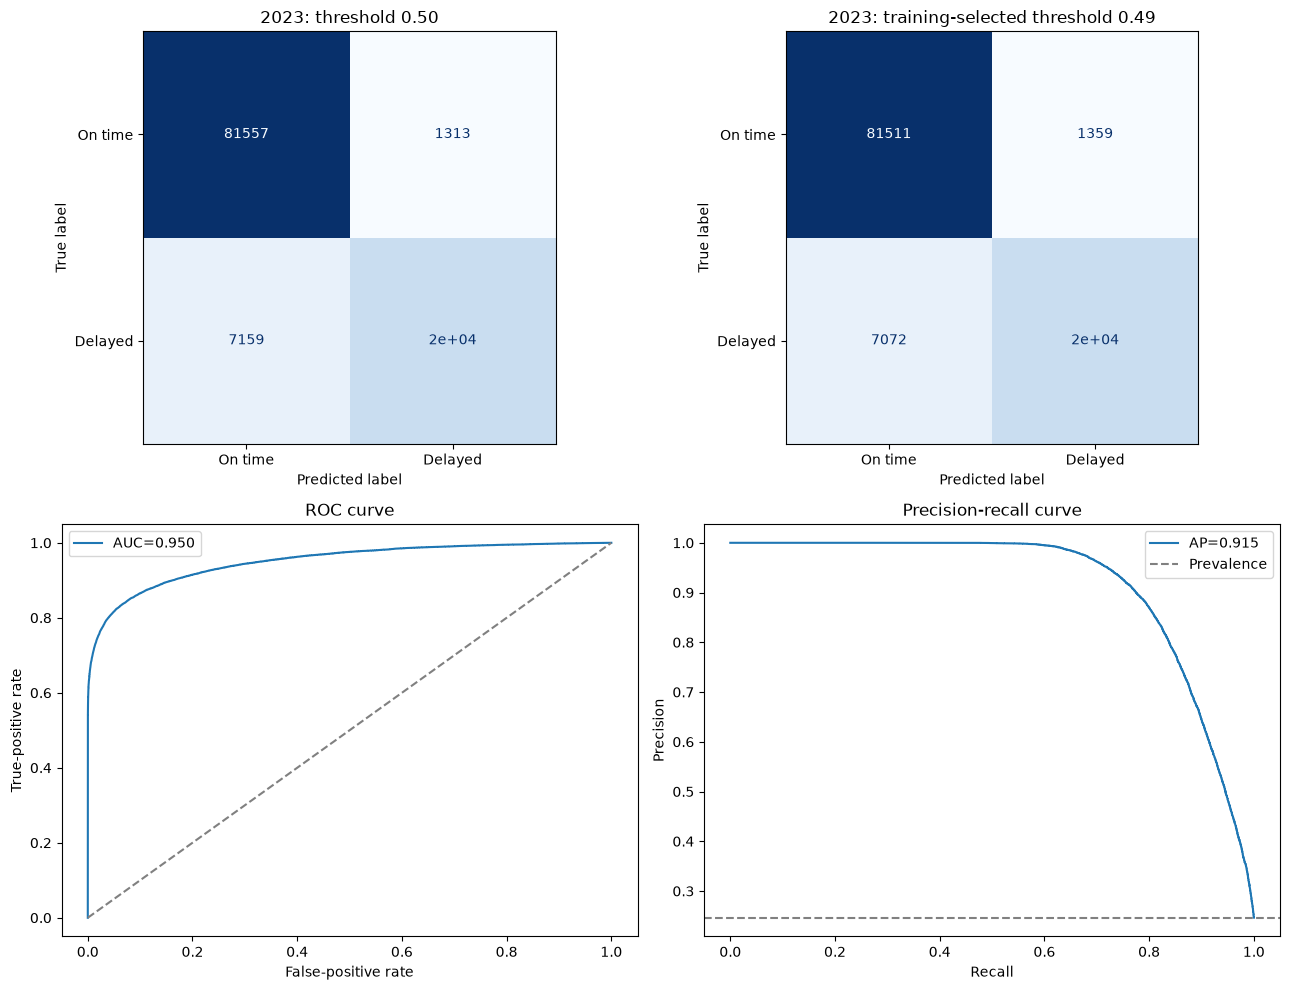

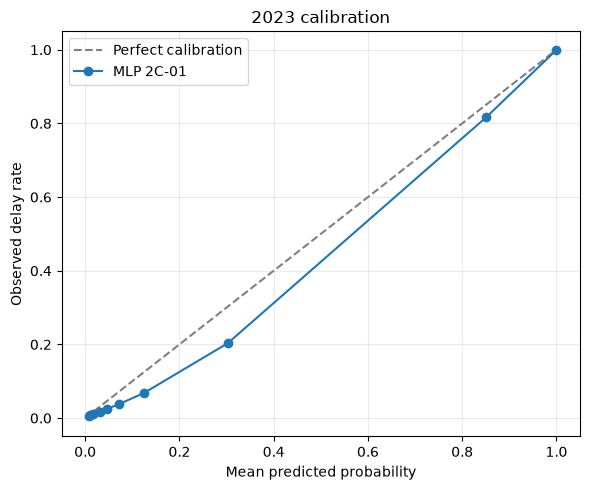

In [9]:
default_predictions = (validation_probabilities >= 0.50).astype(int)
selected_predictions = (
    validation_probabilities >= selected_threshold
).astype(int)
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_validation, validation_probabilities
)
curve_precision, curve_recall, _ = precision_recall_curve(
    y_validation, validation_probabilities
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    default_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("2023: threshold 0.50")
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    selected_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title(
    f"2023: training-selected threshold {selected_threshold:.2f}"
)
axes[1, 0].plot(
    false_positive_rate,
    true_positive_rate,
    label=f"AUC={roc_auc_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 0].set(
    xlabel="False-positive rate",
    ylabel="True-positive rate",
    title="ROC curve",
)
axes[1, 0].legend()
axes[1, 1].plot(
    curve_recall,
    curve_precision,
    label=(
        f"AP={average_precision_score(y_validation, validation_probabilities):.3f}"
    ),
)
axes[1, 1].axhline(
    y_validation.mean(), linestyle="--", color="gray", label="Prevalence"
)
axes[1, 1].set(
    xlabel="Recall",
    ylabel="Precision",
    title="Precision-recall curve",
)
axes[1, 1].legend()
fig.tight_layout()
plt.show()

predicted, observed = calibration_curve(
    y_validation,
    validation_probabilities,
    n_bins=10,
    strategy="quantile",
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(predicted, observed, marker="o", label="MLP 2C-01")
ax.set(
    xlabel="Mean predicted probability",
    ylabel="Observed delay rate",
    title="2023 calibration",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Inspect source-field importance and publishable values

Permutation importance measures the decrease in average precision after one source field is shuffled in a fixed 5,000-row 2023 diagnostic sample. It describes the fitted network; it is not used to change the model or select another experiment.

In [10]:
importance_sample_indices = (
    validation_model_df
    .sample(n=min(5_000, len(validation_model_df)), random_state=RANDOM_STATE)
    .index
    .to_numpy()
)
importance_source = X_validation.iloc[importance_sample_indices].copy()
importance_y = y_validation.iloc[importance_sample_indices].to_numpy()
importance_base_x = np.asarray(
    final_preprocessor.transform(importance_source), dtype=np.float32
)
importance_base_p = best_mlp_model.predict(
    importance_base_x, batch_size=2048, verbose=0
).ravel()
importance_base_ap = average_precision_score(importance_y, importance_base_p)
rng = np.random.default_rng(RANDOM_STATE)
permutation_rows = []

for column in MODEL_COLUMNS:
    permuted = importance_source.copy()
    permuted[column] = rng.permutation(permuted[column].to_numpy())
    permuted_x = np.asarray(
        final_preprocessor.transform(permuted), dtype=np.float32
    )
    permuted_p = best_mlp_model.predict(
        permuted_x, batch_size=2048, verbose=0
    ).ravel()
    permuted_ap = average_precision_score(importance_y, permuted_p)
    permutation_rows.append({
        "feature": column,
        "permuted_average_precision": permuted_ap,
        "average_precision_decrease": importance_base_ap - permuted_ap,
    })

permutation_importance = (
    pd.DataFrame(permutation_rows)
    .sort_values("average_precision_decrease", ascending=False)
    .reset_index(drop=True)
)
display(permutation_importance.head(20))

default = evaluation_results.loc["MLP 2C-01 (default)"]
selected = evaluation_results.loc["MLP 2C-01 (training-selected)"]
publishable_summary = pd.Series({
    "selected representation": "raw_taxi_margin_spline",
    "saved source fields": len(SOURCE_FEATURES),
    "calculated model-side fields": 1,
    "prepared input columns": final_train_x.shape[1],
    "hidden units": str(selected_parameters["hidden_units"]),
    "learning rate": selected_parameters["learning_rate"],
    "L2": selected_parameters["l2"],
    "batch size": selected_parameters["batch_size"],
    "selected epochs": selected_epochs,
    "trainable parameters": best_mlp_model.count_params(),
    "training CV AP": best_candidate["mean_average_precision"],
    "fixed-epoch OOF AP": average_precision_score(oof_y, oof_p),
    "validation prevalence": y_validation.mean(),
    "validation AP": default["average_precision"],
    "validation ROC AUC": default["roc_auc"],
    "validation Brier": default["brier_score"],
    "selected threshold": selected_threshold,
    "selected-threshold accuracy": selected["accuracy"],
    "selected-threshold balanced accuracy": selected["balanced_accuracy"],
    "selected-threshold precision": selected["precision"],
    "selected-threshold recall": selected["recall"],
    "selected-threshold F1": selected["f1"],
    "selected-threshold MCC": selected["mcc"],
    "search seconds": search_seconds,
    "OOF seconds": oof_seconds,
    "final fit seconds": final_fit_seconds,
}, name="MLP 2C Experiment 01 Appendix F values")
publishable_summary.to_frame()

E0000 00:00:1787075964.667952  986126 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,feature,permuted_average_precision,average_precision_decrease
0,DepDelay,0.5313,0.3724
1,MINUTES_TO_SCHEDULED_ARRIVAL,0.5572,0.3465
2,SCHEDULED_SPEED_PROXY,0.7690,0.1347
3,TaxiOut,0.8712,0.0324
4,CRSElapsedTime,0.8834,0.0203
5,ACTUAL_TAKEOFF_TIME_SIN,0.8931,0.0105
6,Origin,0.8936,0.0101
7,LOG_DISTANCE,0.8946,0.0091
8,ACTUAL_TAKEOFF_TIME_COS,0.8962,0.0075
9,SCHED_DEP_TIME_SIN,0.8962,0.0075


,MLP 2C Experiment 01 Appendix F values
selected representation,raw_taxi_margin_spline
saved source fields,31
calculated model-side fields,1
prepared input columns,108
hidden units,"(64, 32)"
learning rate,0.0010
L2,0.0001
batch size,512
selected epochs,11
trainable parameters,9473


## Interpretation checklist

1. Does the largest network win the 2019 temporal comparison, or is a smaller architecture sufficient?
2. Does the selected MLP improve average precision or probability quality over Logistic Regression 2C-02?
3. Are its errors different enough to justify testing it as an ensemble component?
4. Keep the existing saved arrival feature dataset unchanged.
5. Keep the 2024 dataset untouched until the final classifier, ensemble, and threshold are selected.